In [1]:
# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds
import cv2

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

2025-05-02 11:42:30.507498: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-02 11:42:30.514292: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-02 11:42:30.534412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746166350.568627    4296 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746166350.578670    4296 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746166350.604091    4296 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [2]:
# Cell 2: Load EMNIST (digits only)
(ds_train, ds_test), ds_info = tfds.load(
    'emnist/digits',
    split=['train', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

# Preprocessing function
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0  # normalize
    image = tf.image.rot90(image, k=1)          # rotate to upright
    image = tf.image.flip_left_right(image)     # correct mirror issue
    return image, label

# Apply preprocessing
ds_train = ds_train.map(preprocess).batch(128).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(preprocess).batch(128).prefetch(tf.data.AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

...

2025-05-02 11:43:50.431306: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Shuffling /home/user/tensorflow_datasets/emnist/digits/incomplete.6X90DR_3.1.0/emnist-train.tfrecord*...:   0%…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /home/user/tensorflow_datasets/emnist/digits/incomplete.6X90DR_3.1.0/emnist-test.tfrecord*...:   0%|…

Dataset emnist downloaded and prepared to /home/user/tensorflow_datasets/emnist/digits/3.1.0. Subsequent calls will reuse this data.


In [21]:
# Cell 3: Define the model
model = keras.models.Sequential([
    keras.layers.Conv2D(32, 3, activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPool2D(),
    keras.layers.Conv2D(64, 3, activation='relu'),
    keras.layers.MaxPool2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Cell 4: Train the model
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=5  # can increase this if time permits
)

Epoch 1/5
   2/1875 ━━━━━━━━━━━━━━━━━━━━ 1:38 53ms/step - accuracy: 0.1660 - loss: 2.2920

2025-05-02 11:45:13.852442: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 30ms/step - accuracy: 0.9450 - loss: 0.1918 - val_accuracy: 0.9904 - val_loss: 0.0305
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9912 - loss: 0.0297 - val_accuracy: 0.9937 - val_loss: 0.0209
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9940 - loss: 0.0206 - val_accuracy: 0.9941 - val_loss: 0.0193
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9955 - loss: 0.0154 - val_accuracy: 0.9945 - val_loss: 0.0184
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9967 - loss: 0.0113 - val_accuracy: 0.9941 - val_loss: 0.0216


In [5]:
# Cell 5: Save the model
model.save('../model/2nddigit_emnist_model.h5')

In [6]:
# Cell 6: Load and test prediction on a captured image
model = keras.models.load_model('../model/2nddigit_emnist_model.h5')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Digit: 4


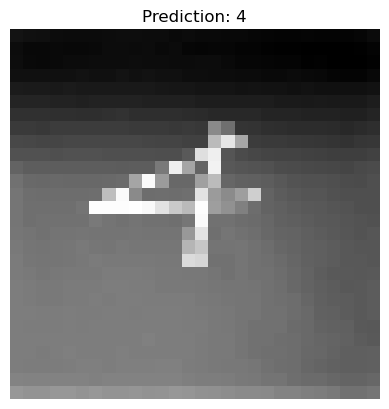

In [22]:
img_path = '../captured_images/digit20.jpeg'  # Update as per your file
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28,28))
img = 255 - img   # Invert: white digit on black
img = img.astype('float32') / 255.0
img = np.expand_dims(img, axis=(0, -1))  # shape: (1,28,28,1)

# Predict
pred = model.predict(img)
digit = np.argmax(pred)
print("Predicted Digit:", digit)

# Display
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Prediction: {digit}")
plt.axis('off')
plt.show()